Switched to EMA parameters for inference


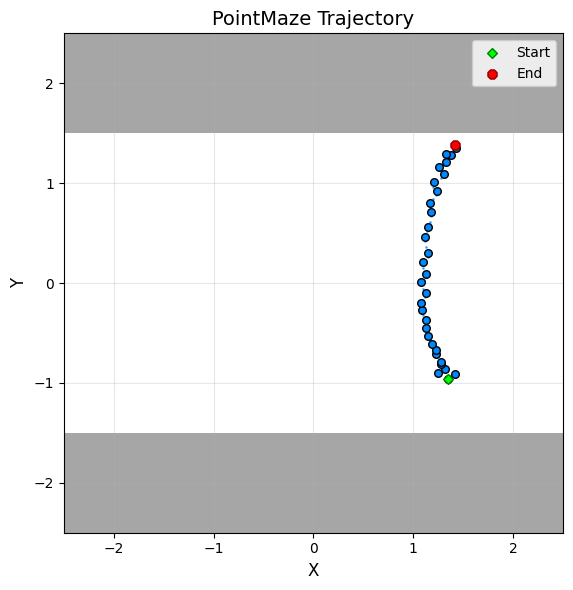

Task 001 | len=  65 | start_err=0.072 | goal_err=0.008 | ✓
k invalid
k invalid


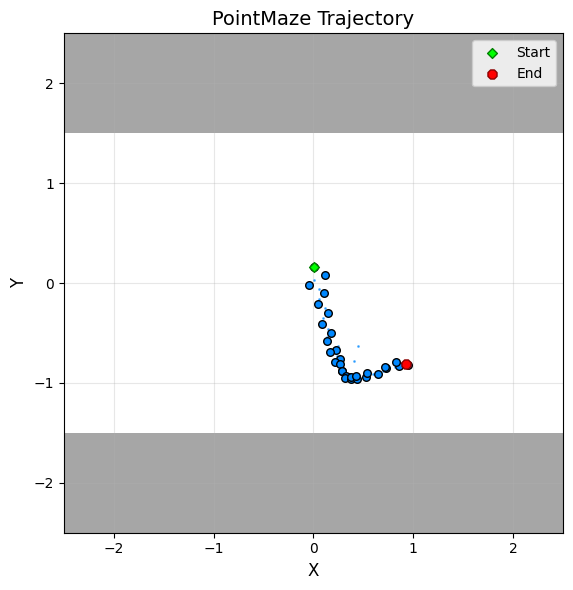

Task 002 | len=  53 | start_err=0.067 | goal_err=0.017 | ✓


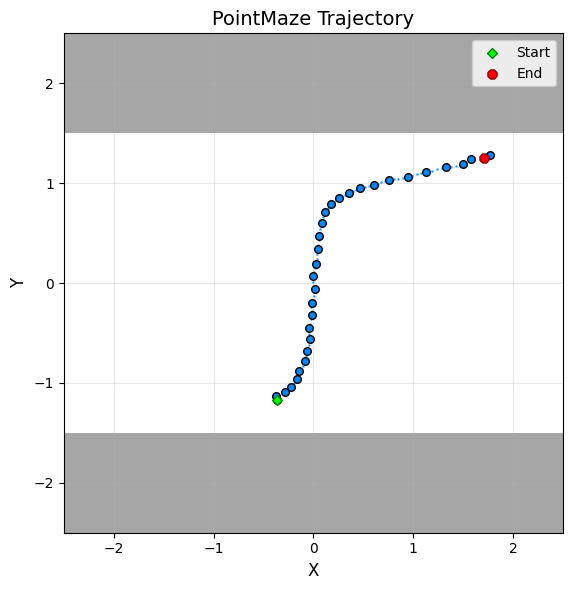

Task 003 | len=  90 | start_err=0.016 | goal_err=0.075 | ✓
k invalid
k invalid


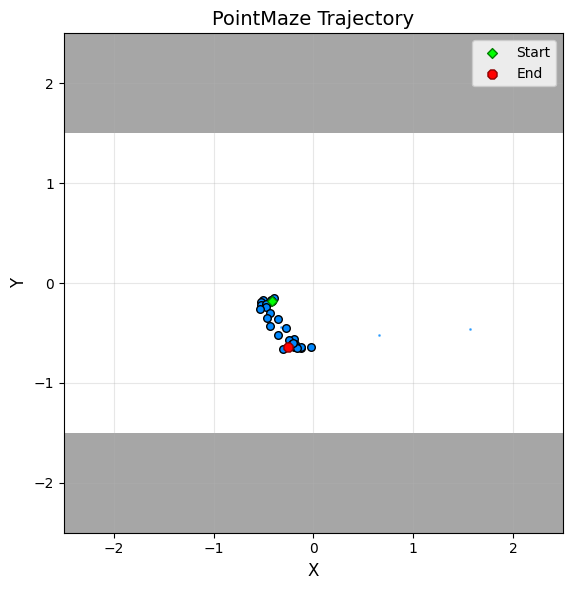

Task 004 | len=  55 | start_err=0.042 | goal_err=0.266 | ✗
k invalid
k invalid
k invalid
k invalid
k invalid
k invalid


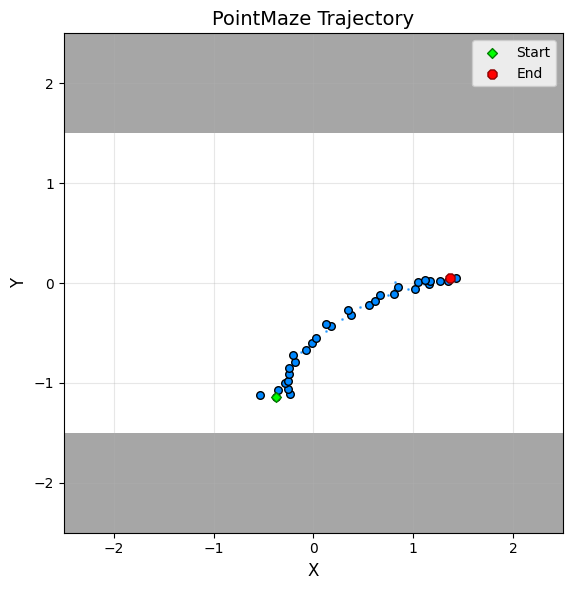

Task 005 | len=  51 | start_err=0.027 | goal_err=0.022 | ✓


KeyboardInterrupt: 

In [ ]:
import yaml
import numpy as np
import torch
from timeskip_diffuser.diffuser.nets import EqNet, TemporalUNet
from timeskip_diffuser.diffuser.diffusion import GaussianDiffusion
from timeskip_diffuser.diffuser.trainer import DiffuserTrainer
from timeskip_diffuser.diffuser.planner import DiffuserPlanner, expand_spline_from_skip_list
from timeskip_diffuser.datasets.point_maze.offline_skip.offline_skip import OfflineSkipDataset
from timeskip_diffuser.datasets.point_maze.umaze import UMazeFlatDataset
from timeskip_diffuser.datasets.point_maze.medium import MediumFlatDataset
from timeskip_diffuser.datasets.point_maze.open import OpenFlatDataset
from timeskip_diffuser.datasets.point_maze.offline_skip.traj_verifiers.verifier import (
    extract_wall_rects, verify_trajectory_dense, endpoint_within_eps
)
from timeskip_diffuser.diffuser.reward import CompositeReward, StartReachingReward, GoalReachingReward, TotalTimeSkipPenalty, CurvaturePenalty, LogSkipReward


import os
from datetime import datetime
import argparse
import yaml

# -----------------------------
# Hardcoded experiment params
# -----------------------------

GUIDANCE_SCALE = 1.0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# Load config
# -----------------------------

with open("experiments_config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

env_name = cfg["env"]
arch = cfg["model"]["architecture"]
use_skips = cfg["model"]["skips"]

task_file = cfg["paths"]["task_file"]
ckpt_file = cfg["paths"]["ckpt_file"]
dataset_file = cfg["paths"].get("dataset_file", None)

HORIZON = cfg["testing"]["horizon"]
MAX_TRIES = cfg["testing"]["max_tries"]
results = []

# -----------------------------
# Load start / goal tasks
# -----------------------------
tasks = np.load(task_file)
starts = tasks["starts"]
goals = tasks["goals"]
assert len(starts) == len(goals)
"""
starts = [[-1, -1]]
goals = [[1, -1]]
"""
#dataset_vis = OpenFlatDataset(horizon=HORIZON)

# -----------------------------
# Dataset selection
# -----------------------------
if use_skips:
    assert dataset_file is not None, "dataset_file required when skips=true"
    dataset = OfflineSkipDataset(dataset_file, dataset_id="D4RL/pointmaze/open-v2", horizon=HORIZON)
    state_dim = dataset.traj_dim
else:
    if env_name == "umaze":
        dataset = UMazeFlatDataset(horizon=HORIZON)
    elif env_name == "medium":
        dataset = MediumFlatDataset(horizon=HORIZON)
    elif env_name == "open":
        dataset = OpenFlatDataset(horizon=HORIZON)
    else:
        raise ValueError(f"Unknown env: {env_name}")
    state_dim = dataset.state_dim

# -----------------------------
# Model selection
# -----------------------------
if arch == "eqnet":
    model = EqNet(
        state_dim=state_dim,
        hidden_dim=128,
        time_dim=64,
        n_layers=10,
    )
elif arch == "unet":
    model = TemporalUNet(
        state_dim=state_dim,
        time_dim=64,
    )
else:
    raise ValueError(f"Unknown architecture: {arch}")

# -----------------------------
# Diffusion + planner
# -----------------------------
diffusion = GaussianDiffusion(timesteps=200)
trainer = DiffuserTrainer(
    model=model,
    diffusion=diffusion,
    dataset=dataset,
    device=DEVICE,
)
trainer.use_ema_for_inference()
trainer.load_checkpoint(ckpt_file)

planner = DiffuserPlanner(model, diffusion, dataset, device=DEVICE)

# -----------------------------
# Evaluation loop
# -----------------------------
wall_rects = extract_wall_rects(f"D4RL/pointmaze/{env_name}-v2")
successes = 0

for i, (start, goal) in enumerate(zip(starts, goals)):
    solved = False

    for _ in range(MAX_TRIES):
        reward_fn = CompositeReward(
            [
                StartReachingReward(start, reward_scale=5.0),
                GoalReachingReward(goal, reward_scale=5.0),
                CurvaturePenalty(reward_scale=0.1),
                # Only meaningful if skips=True
                TotalTimeSkipPenalty(reward_scale=0.005),
            ]
        )
        if use_skips:
            traj = planner.plan_and_reconstruct(
                current_obs=start[:2],
                goal_obs=goal,
                horizon=HORIZON,
                guidance_scale=GUIDANCE_SCALE,
                reward_fn=reward_fn,
                condition_on_start=True,
                condition_on_goal=True,
                conditioning_schedule="constant",
                conditioning_strength=0.9,
                spline_func=expand_spline_from_skip_list,
            )
            pos = traj["pos_dense"]
            dataset.visualize(traj["coarse"])
            
        else:
            traj = planner.plan(
                current_obs=start[:2],
                goal_obs=goal,
                reward_fn=reward_fn,
                horizon=HORIZON,
                guidance_scale=GUIDANCE_SCALE,
                condition_on_start=True,
                condition_on_goal=True,
                conditioning_schedule="constant",
                conditioning_strength=0.9,
            )
            pos = traj
        
        start_error = np.linalg.norm(pos[0] - start[:2])
        goal_error  = np.linalg.norm(pos[-1] - goal)
        
        feasible, _ = verify_trajectory_dense(pos, wall_rects)
        start_ok, goal_ok, _, _ = endpoint_within_eps(
            pos, start, goal, 0.20, 0.20
        )

        if feasible and start_ok and goal_ok:
            successes += 1
            solved = True
            break
            
    results.append({
        "task_id": i,
        "start": start.tolist(),
        "goal": goal.tolist(),
        "solved": solved,
    })
    print(
        f"Task {i+1:03d} | "
        f"len={len(pos):4d} | "
        f"start_err={start_error:.3f} | "
        f"goal_err={goal_error:.3f} | "
        f"{'✓' if solved else '✗'}"
    )

# -----------------------------
# Summary
# -----------------------------
print("\n==============================")
print(f"Tasks        : {len(starts)}")
print(f"Successes    : {successes}")
print(f"Success rate : {successes / len(starts):.3f}")
print("==============================")


work_dir = cfg["paths"]["work_dir"]
os.makedirs(work_dir, exist_ok=True)

arch_name = arch
skips_name = "skips" if use_skips else "flat"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

out_file = os.path.join(
    work_dir,
    f"experiment_{env_name}_{arch_name}_{skips_name}_{timestamp}.txt"
)

with open(out_file, "w") as f:
    f.write(f"env={env_name}\n")
    f.write(f"architecture={arch}\n")
    f.write(f"skips={use_skips}\n")
    f.write(f"horizon={HORIZON}\n")
    f.write(f"max_tries={MAX_TRIES}\n")
    f.write(f"success_rate={successes / len(starts):.3f}\n\n")

    for r in results:
        f.write(
            f"task={r['task_id']:03d} "
            f"start={r['start']} "
            f"goal={r['goal']} "
            f"solved={r['solved']}\n"
        )